In [1]:
import os,sys
import time
# PROJECT_ROOT = "/home/ziqih2/Alex's sample code"
# if PROJECT_ROOT not in sys.path:
#     sys.path.insert(0, PROJECT_ROOT)
# os.chdir(PROJECT_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

import sklearn
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
from tqdm import tqdm
import torch
import torch.optim as optim
import importlib
from training2D import Trainer

from models2D import Generator, Discriminator
from os import mkdir

from tqdm.auto import tqdm
from sklearn import datasets
import sklearn
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from inf_train_gen import inf_train_gener
from scipy.stats import wasserstein_distance
import ot


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [2]:
# compute weights for random picking posterior
def compute_weights(data,A, y):
    sigma = 0.5
    x = np.transpose(data)
    W_tilde_array = np.zeros((n,1))
    W_array = np.zeros(n)
    for i in range(n):
        x_i = np.reshape(data[i],(2,1))
        W_tilde = np.exp(-(1/(2*sigma**2))*np.linalg.norm(A*x_i-y)**2)
        W_tilde_array[i] = W_tilde
    W_sum = np.sum(W_tilde_array)
    for j in range(n):
        W = W_tilde_array[j]/W_sum
        W_array[j]= W
    return W_array

In [3]:
# compute Wasserstein-2 distance
def W2_distance(X,Y):
    n = X.shape[0]  
    m = Y.shape[0]  
    # normalizing weights
    a = np.ones(n) / n
    b = np.ones(m) / m

    M = ot.dist(X, Y, metric='euclidean') ** 2

    W2 = ot.emd2(a, b, M)
    W = np.sqrt(W2)
    return W
    print("Wasserstein distance:", W)

In [4]:
# compute Wasserstein-1 distance
def W1_distance(X,Y):
    n = X.shape[0]  
    m = Y.shape[0] 

    # normalizing weights
    a = np.ones(n) / n
    b = np.ones(m) / m

    M = ot.dist(X, Y, metric='euclidean')
    W1 = ot.emd2(a, b, M)
    return W1
    print("Wasserstein distance:", W)

In [5]:
def plot_sample(samples):
    plt.hist2d(samples[:,0],samples[:,1],100)
    plt.show()

In [6]:
# define function G for sequential generator
def G(X, k, g_list):
    x_lat = X
    for j in range(int(k)):
        x_lat = g_list[j](x_lat.to(device))
    return x_lat

In [7]:
# use random choosing to compute posterior
def compute_posterior(Y_in):
    A = np.matrix([[1.0,0.0],[0.0,0.0]])
    x_d = np.matrix([0,0])
    x_d = np.transpose(x_d)
    y = A@x_d
    weight = compute_weights(Y_in,A,y)
    num_samples = 10000
    samples = np.transpose(Y_in)
    prob = weight.flatten() / np.sum(weight)
    resampled_indices = np.random.choice(len(prob), size=num_samples, replace=True, p=prob)
    resampled_samples = samples[:, resampled_indices]  
    return np.transpose(resampled_samples) 

In [8]:
# hyperparameters
configs = {
    "dataset": "darcy_flow",
    "momentum": 0,
    "gp_weight": 5,
    "batch_size": 512,
    "latent_dim": 2,
    "num_epochs": 10000,
    "penalty_type": "monge",
    "num_datapoints": 10000,
    "monotone_penalty": 0.0,
    "critic_iterations": 5,
    "full_critic_train": 20,
    "critic_learning_rate": 0.01,
    "gradient_penalty_type": "two_sided",
    "gen_hidden_layer_sizes": [
        128, 128, 128
    ],
    "generator_learning_rate": 0.01,
    "discriminator_hidden_layer_sizes": [
        128, 128, 128
    ],
    "device":'cuda'
}

In [9]:
device = configs['device']
print(device)
prior = 'pinwheel'

cuda


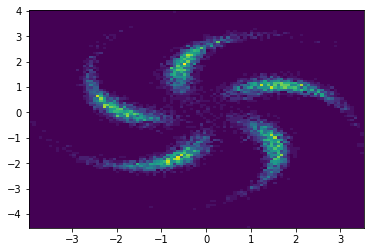

/tmp/ipykernel_441984/3374277484.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset = TensorDataset(torch.tensor(np.zeros((n,1)),dtype=torch.float), torch.tensor(X,dtype=torch.float), torch.tensor(np.zeros((n,1)),dtype=torch.float),torch.tensor(Y_org,dtype=torch.float))


In [10]:
# compute the original sample
k = 5
n = configs['num_datapoints']
Y_org = inf_train_gener(prior,batch_size = n)
plt.hist2d(Y_org[:,0],Y_org[:,1],100)
plt.savefig('Original_sample.jpg')
plt.show()
X = torch.randn((n, 2))
dataset = TensorDataset(torch.tensor(np.zeros((n,1)),dtype=torch.float), torch.tensor(X,dtype=torch.float), torch.tensor(np.zeros((n,1)),dtype=torch.float),torch.tensor(Y_org,dtype=torch.float))
data_loader = DataLoader(dataset, batch_size=configs['batch_size'], shuffle=True)

/tmp/ipykernel_441984/1610261824.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W_array[j]= W


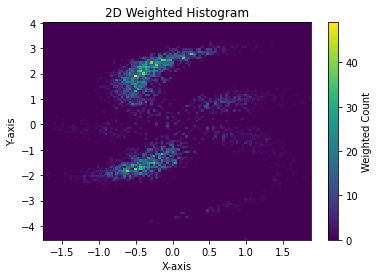

In [11]:
# compute true posterior
Y_org_sample = compute_posterior(Y_org)
plt.hist2d(Y_org_sample[:,0], Y_org_sample[:,1], bins=(100, 100), cmap=plt.cm.viridis)
plt.colorbar(label='Weighted Count')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('2D Weighted Histogram')
plt.savefig('y.jpg')
plt.show()

In [ ]:
# initialize setting up of generators, and the list of epochs
cond_in, gen_in, cond,gen=data_loader.dataset.tensors
condition_dim = 0
sample_dim = 2
generator_list = []

G_fun_list_all = []
epochs = [256, 512, 1024, 2048, 4096]
width = 128

In [ ]:
# initialize the generator for each sequence and each repeated testing
for epoch in epochs:
    print(epoch)
    G_fun_list = []
    for j in range(5):
        generator_list = []
        for i in range(int(5)):
            generator = Generator(
                condition_dim=condition_dim,
                sample_dim=sample_dim,
                hidden_layer_sizes=[width, width, width], 
                sample_latent = X
                )

            discriminator = Discriminator(
                condition_dim=condition_dim,
                sample_dim=sample_dim,
                hidden_layer_sizes=[width, width, width],
                )
            G_optimizer = optim.SGD(generator.parameters(), lr=configs['generator_learning_rate'],momentum = configs['momentum'])
            D_optimizer = optim.SGD(discriminator.parameters(), lr=configs['critic_learning_rate'],momentum = configs['momentum'])
            generator.load_state_dict(torch.load('./Training_epochs_model_'+prior+'/'+str(epoch)+'/'+str(j+1)+'/generator_for_WGANGP-10000_'+str(i)+'.pth'))
            generator.eval()
            generator = generator.to(device)
            generator_list.append(generator)
        G_fun_list.append(generator_list)
    G_fun_list_all.append(G_fun_list)


/tmp/ipykernel_441984/3148548036.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load('./Training_epochs_model_'+prior+'/'+str(epoch)+'/

256
512
1024
2048
4096


In [14]:
m = 10000
X_latent = torch.randn((m, 2)).to(device)


In [ ]:
# generate prior and posterior and compute W1 distance of posterior and W2 distance of prior for each testing
W_list_all = []
W_list_all_2 = []
for g_list in G_fun_list_all:
    W_list = []
    W_list_2 = []
    k = 5
    for g in g_list:
        GY = G(X_latent, k, g).cpu().detach().numpy()
        W2 = W2_distance(Y_org, GY)

        Y = compute_posterior(GY)
        W1 = W1_distance(Y_org_sample, Y)
        W_list.append(W1)
        W_list_2.append(W2)

    W_list_all_2.append(W_list_2)
    W_list_all.append(W_list)

/home/ziqih2/.local/lib/python3.10/site-packages/ot/lp/__init__.py:630: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)
/tmp/ipykernel_441984/1610261824.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W_array[j]= W


In [ ]:
# compute mean and standard deviation of W1 distance of posterior and W2 distance of prior
w_err = []
w_std = []
w_err_2 = []
w_std_2 = []
for w in W_list_all:
    avg_err = sum(w) / len(w)
    w_err.append(avg_err)
    std = np.std(w)
    w_std.append(std)
for w_2 in W_list_all_2:
    avg_err_2 = sum(w_2)/len(w_2)
    w_err_2.append(avg_err_2)
    std_2 = np.std(w_2)
    w_std_2.append(std_2)

In [18]:
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor']   = 'white'
mpl.rcParams['savefig.facecolor']= 'white'


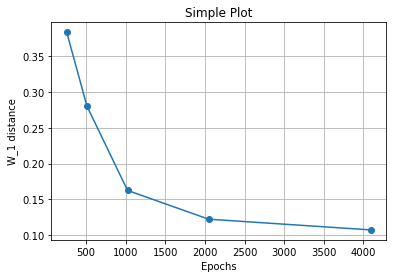

In [19]:
plt.plot(epochs, w_err, marker='o')  
plt.xlabel("Epochs")
plt.ylabel("W_1 distance")
plt.title("Simple Plot")
plt.grid(True)
plt.show()

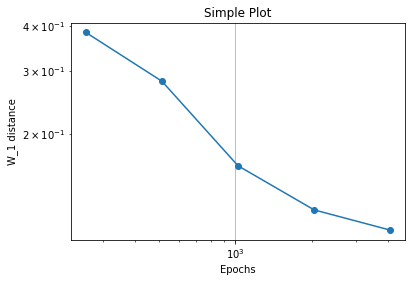

In [20]:
plt.loglog(epochs, w_err, marker='o')  
plt.xlabel("Epochs")
plt.ylabel("W_1 distance")
plt.title("Simple Plot")
plt.grid(True)
plt.show()

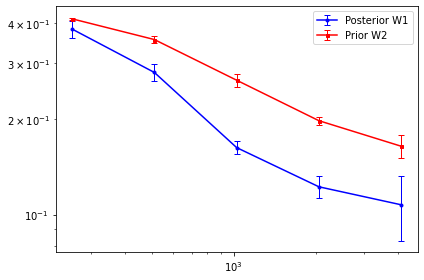

In [ ]:
# Plot W1 distance of posterior and W2 distance of prior together with loglog scale
fig, ax = plt.subplots()
ax.errorbar(epochs, w_err,   yerr=w_std,   fmt='o-', color='blue', ecolor='blue',
            elinewidth=1, capsize=3, markersize=3, label='Posterior W1')
ax.errorbar(epochs, w_err_2, yerr=w_std_2, fmt='s-', color='red',  ecolor='red',
            elinewidth=1, capsize=3, markersize=3, label='Prior W2')

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right')

fig.tight_layout()
fig.savefig('w_plot_single_axis.png', dpi=300, bbox_inches='tight')

In [ ]:
# compute loglog slope of W1 distance of posterior
log_x = np.log(epochs)
log_y = np.log(w_err)
slope, intercept = np.polyfit(log_x, log_y, 1)
print(slope)

-0.4862140981319042


In [ ]:
# compute loglog slope of W2 distance of prior
log_x = np.log(epochs)
log_y = np.log(w_err_2)
slope, intercept = np.polyfit(log_x, log_y, 1)
print(slope)

-0.3507226058936995
